# Hands-on Sesi 12

Nama Lengkap : Dikki Frana Alvian

NIM : 240401010151

Kelas : IF403

Link : https://colab.research.google.com/drive/1m-1fGyC3OyFp0cC3AWpakqTya_vUktr-?usp=sharing

# 1. Generate & Eksplorasi Dataset Transaksi

In [13]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

Contoh transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50


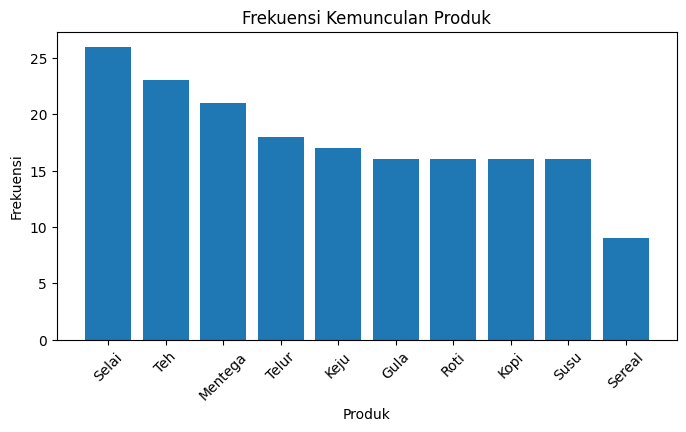

In [15]:
product_counts = df.sum().sort_values(ascending=False)

freq_df = pd.DataFrame({
    "Produk": product_counts.index,
    "Frekuensi": product_counts.values
})

plt.figure(figsize=(8,4))
plt.bar(freq_df["Produk"], freq_df["Frekuensi"])
plt.title("Frekuensi Kemunculan Produk")
plt.xlabel("Produk")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.show()

# 2. One-Hot Encoding Transaksi

In [16]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(te_ary, columns=te.columns_)

print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


# 3. Cari Frequent Itemset dengan Apriori

In [17]:
from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

# Gunakan min_support yang menghasilkan jumlah itemset wajar (tidak 0, tidak ratusan)
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print(freq_items.head(10))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Selai, Teh)


# 4. Bentuk & Saring Aturan Asosiasi

In [18]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_items, metric='confidence',
                           min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)

print(rules[['antecedents', 'consequents',
             'support', 'confidence', 'lift']].head(10))

         antecedents consequents  support  confidence      lift
10       (Keju, Teh)     (Telur)     0.12    0.857143  2.380952
13  (Mentega, Selai)      (Kopi)     0.10    0.625000  1.953125
11      (Roti, Gula)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
9       (Telur, Teh)      (Keju)     0.12    0.600000  1.764706
15     (Selai, Kopi)   (Mentega)     0.10    0.714286  1.700680
8      (Telur, Keju)       (Teh)     0.12    0.750000  1.630435
12     (Gula, Selai)      (Roti)     0.10    0.500000  1.562500
14   (Mentega, Kopi)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115


## Interpretasi Pendekatan Association Rules

Berdasarkan hasil Association Rules, aturan dengan **nilai Lift tertinggi** adalah:

**{Keju, Teh} → {Telur}**

dengan nilai:
- Support = 0.12
- Confidence = 0.857
- Lift = 2.381

Aturan tersebut menunjukkan bahwa sekitar **85,7% transaksi yang mengandung Keju dan Teh juga mengandung Telur**. Nilai **Lift sebesar 2.381** menunjukkan bahwa kemunculan Telur pada transaksi yang berisi Keju dan Teh sekitar **2,38 kali lebih besar** dibandingkan peluang kemunculan Telur secara umum, sehingga hubungan antarproduk tersebut tergolong kuat.

Selain itu, aturan **Roti → Selai** juga memiliki **Confidence sebesar 0.688** dan **Lift sebesar 1.322**. Hal ini menunjukkan bahwa pelanggan yang membeli Roti cenderung juga membeli Selai, meskipun kekuatan hubungannya tidak sekuat aturan {Keju, Teh} → {Telur}.

Secara bisnis, aturan-aturan tersebut dapat dimanfaatkan sebagai dasar rekomendasi produk atau strategi penempatan barang agar produk yang sering dibeli bersama lebih mudah ditemukan oleh pelanggan.

# 5. Rekomender Sederhana dengan Content-Based Filtering

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery','Bakery','Dairy','Bakery','Dairy',
                 'Dairy','Minuman','Bumbu','Minuman','Dairy']
})

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()
print('Mirip dengan Roti:', rekomendasi_serupa('Roti'))

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


## Interpretasi Pendekatan 'Content-Based Filtering'

Metode Content-Based Filtering memberikan rekomendasi produk yang memiliki kategori serupa dengan produk yang dipilih. Untuk produk **Roti**, sistem merekomendasikan **Selai, Sereal, dan Susu**.

Rekomendasi tersebut diperoleh berdasarkan kemiripan atribut kategori menggunakan **Cosine Similarity**, sehingga produk dengan karakteristik yang mirip memiliki nilai kemiripan yang lebih tinggi. Pendekatan ini tidak mempertimbangkan riwayat pembelian pelanggan, melainkan hanya memanfaatkan informasi atribut produk.

# 6. Bandingkan Kedua Pendekatan

In [12]:
produk_target = 'Roti'
# Dari association rules: cari consequents dari aturan yang antecedent-nya mengandung produk_target
rules_terkait = rules[rules['antecedents'].apply(
lambda x: produk_target in x)]
print('Rekomendasi dari Association Rules:')
print(rules_terkait[['consequents', 'lift']].head())
print('Rekomendasi dari Content-Based:', rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:
   consequents      lift
11     (Selai)  1.923077
1      (Selai)  1.322115
Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


## Interpretasi Perbandingan Antara Pendekatan 'Association Rules' dan 'Content-Based Filtering'

Berdasarkan hasil yang diperoleh, kedua pendekatan sama-sama merekomendasikan **Selai** untuk produk **Roti**, sehingga hasil yang diberikan cukup konsisten.

Perbedaannya adalah:

- **Association Rules** menghasilkan rekomendasi berdasarkan pola pembelian pelanggan pada data transaksi. Oleh karena itu rekomendasi mencerminkan kebiasaan konsumen dalam membeli produk secara bersamaan.
- **Content-Based Filtering** memberikan rekomendasi berdasarkan kemiripan atribut produk tanpa memerlukan riwayat transaksi pengguna.

Association Rules lebih sesuai digunakan apabila tersedia data transaksi yang cukup banyak, sedangkan Content-Based Filtering lebih tepat digunakan ketika atribut produk tersedia namun histori transaksi masih terbatas.
Kedua metode dapat digabungkan (Hybrid) untuk mendapat rekomendasi yang lebih akurat.